In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

### Load and inspect data

In [2]:
# Adult Income dataset — multiple nominal categorical features
data = fetch_openml(name='adult', version=2, as_frame=True)
df = data.frame.copy()
df.shape

(48842, 15)

In [3]:
df.head(3)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [4]:
df.dtypes

age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
class             category
dtype: object

### Preprocessing

In [5]:
# Drop rows with missing values
df = df.dropna()

# Identify feature types
cat_cols = df.select_dtypes(include=['category', 'object']).columns.tolist()
cat_cols.remove('class')  # target column
num_cols = df.select_dtypes(include=['number']).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numerical columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [6]:
# Encode target
y = (df['class'].astype(str).str.strip() == '>50K').astype(int)
X = df.drop(columns=['class'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (36177, 14), Test size: (9045, 14)


### Build pipelines

In [7]:
from sklearn.preprocessing import StandardScaler

# --- Label Encoding pipeline ---
# OrdinalEncoder maps each category to an integer (same effect as LabelEncoder for features)
from sklearn.preprocessing import OrdinalEncoder

le_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
])

# --- One Hot Encoding pipeline ---
ohe_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_cols)
])

In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

### Run experiment

In [9]:
results = []

for model_name, model in models.items():
    for enc_name, preprocessor in [('Label Encoding', le_preprocessor), ('One Hot Encoding', ohe_preprocessor)]:
        pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
        pipe.fit(X_train, y_train)
        acc = accuracy_score(y_test, pipe.predict(X_test))
        results.append({'Model': model_name, 'Encoding': enc_name, 'Accuracy': acc})
        print(f"{model_name:<22} | {enc_name:<18} | Accuracy: {acc:.4f}")

results_df = pd.DataFrame(results)

Logistic Regression    | Label Encoding     | Accuracy: 0.8172
Logistic Regression    | One Hot Encoding   | Accuracy: 0.8462
KNN                    | Label Encoding     | Accuracy: 0.8180
KNN                    | One Hot Encoding   | Accuracy: 0.8261
Decision Tree          | Label Encoding     | Accuracy: 0.8046
Decision Tree          | One Hot Encoding   | Accuracy: 0.8053
Random Forest          | Label Encoding     | Accuracy: 0.8495
Random Forest          | One Hot Encoding   | Accuracy: 0.8472


### Results table

In [10]:
pivot = results_df.pivot(index='Model', columns='Encoding', values='Accuracy')
pivot['Difference'] = pivot['One Hot Encoding'] - pivot['Label Encoding']
pivot.sort_values('Difference', ascending=False).round(4)

Encoding,Label Encoding,One Hot Encoding,Difference
Model,,,
Logistic Regression,0.8172,0.8462,0.0290
KNN,0.8180,0.8261,0.0081
Decision Tree,0.8046,0.8053,0.0007
Random Forest,0.8495,0.8472,-0.0023


### Visualization

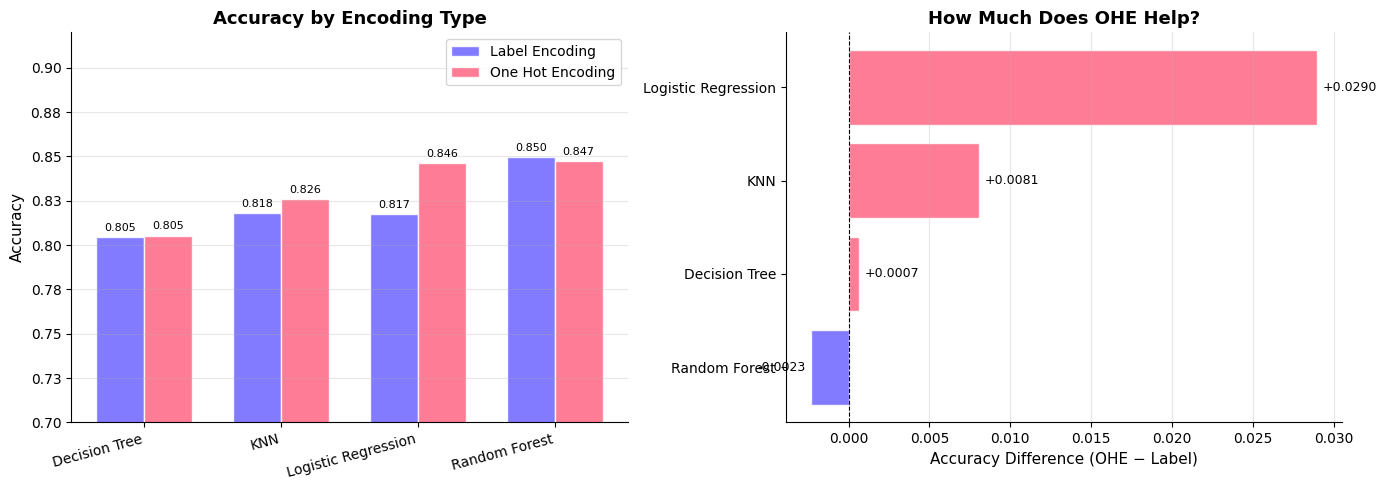

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Grouped bar chart ──────────────────────────────────────────────
model_names = pivot.index.tolist()
x = np.arange(len(model_names))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, pivot['Label Encoding'], width, label='Label Encoding',
                color='#6C63FF', alpha=0.85, edgecolor='white')
bars2 = ax1.bar(x + width/2, pivot['One Hot Encoding'], width, label='One Hot Encoding',
                color='#FF6584', alpha=0.85, edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=15, ha='right', fontsize=10)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Accuracy by Encoding Type', fontsize=13, fontweight='bold')
ax1.set_ylim(0.70, 0.92)
ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

# Add value labels
for bar in [*bars1, *bars2]:
    ax1.annotate(f'{bar.get_height():.3f}',
                 xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 xytext=(0, 3), textcoords='offset points',
                 ha='center', va='bottom', fontsize=8)

# ── Plot 2: Accuracy delta ──────────────────────────────────────────────────
ax2 = axes[1]
diff = pivot['Difference'].sort_values(ascending=True)
colors = ['#FF6584' if d >= 0 else '#6C63FF' for d in diff]

bars = ax2.barh(diff.index, diff.values, color=colors, edgecolor='white', alpha=0.85)
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Accuracy Difference (OHE − Label)', fontsize=11)
ax2.set_title('How Much Does OHE Help?', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, diff.values):
    ax2.annotate(f'{val:+.4f}',
                 xy=(val, bar.get_y() + bar.get_height() / 2),
                 xytext=(4 if val >= 0 else -4, 0), textcoords='offset points',
                 va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('encoding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature dimensionality

In [12]:
# How many features does each encoding produce?
le_preprocessor.fit(X_train)
ohe_preprocessor.fit(X_train)

le_features = le_preprocessor.transform(X_train).shape[1]
ohe_features = ohe_preprocessor.transform(X_train).shape[1]

print(f"Features with Label Encoding : {le_features}")
print(f"Features with One Hot Encoding: {ohe_features}")
print(f"Dimensionality increase       : {ohe_features - le_features} extra columns")

Features with Label Encoding : 14
Features with One Hot Encoding: 96
Dimensionality increase       : 82 extra columns


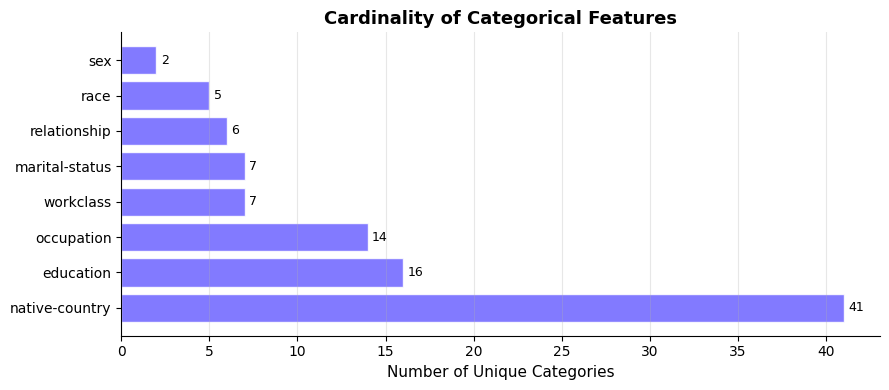

In [13]:
# Category counts per column — shows which columns explode dimensionality the most
cardinality = X_train[cat_cols].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(cardinality.index, cardinality.values, color='#6C63FF', alpha=0.85, edgecolor='white')
ax.set_xlabel('Number of Unique Categories', fontsize=11)
ax.set_title('Cardinality of Categorical Features', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, cardinality.values):
    ax.annotate(str(val), xy=(val, bar.get_y() + bar.get_height() / 2),
                xytext=(3, 0), textcoords='offset points', va='center', fontsize=9)

plt.tight_layout()
plt.show()